# Prosjekt 3
##### Lukas Skjevik & Einar Aarnæs

### Oppgave 1

##### Oppgave 1a)

Vi ønsker å løse likningen $\frac{d^2y}{dy^2} = -4sin(2x), \quad y(0) = 0, \quad y'(0) = 2$.

Ved å antiderivere begge sider mhp. x får vi:

$y(x) = sin(2x) + Bx + C, \quad B, C \in \mathbb{R}$.

Innsatt initialverdibetingelser:

$y'(0) = 2 \implies 2cos(2 \cdot 0) + B = 2 \implies B = 0$

$y(0) = 0 \implies sin(2 \cdot 0) + C = 0 \implies C = 0$

Som gir den endelige løsningen:

$y(x) = sin(2x)$

##### Oppgave 1b)

Vi vil skrive om systemet til et 1. ordens system for vektoren $\vec{y}(x) = \begin{pmatrix} y(x) \\ y'(x) \end{pmatrix}$.

Kan umiddelbart skrive ned at initialbetingelsen er $\vec{y}(0) = \begin{pmatrix} 0 \\ 2 \end{pmatrix}$.

Matrisen vår er lettest å finne ved å la $y(x) = u_1$ og $y'(x) = u_2$. Det gir at $u_1' = u_2$ og $u_2' = -4sin(2x)$. Dette gir likningen

$\vec{y}'(x) = \begin{bmatrix}
    0 & 1 \\
    0 & 0
\end{bmatrix} \vec{y}(x) + \begin{bmatrix}
    0 \\
    -4sin(2x)
\end{bmatrix}
$

##### Oppgave 1c)

In [170]:
import numpy as np
from matplotlib import pyplot as plt
import scipy as sp

In [171]:


def rk_32(x_init, x_end, y_init, f, h0 = 0.1, tol = 1e-7, alpha = 0.8):
    """
    Solves an ivp with a Runge Kutta method.
    
    Args:
        x_init (float): x-value at initial condition
        x_end (float): End of interval to be solved
        y_init (np array): y-value av initial condition
        f (function): Right hand side of the equation
        h0 (float, optional): Intitial guess for step length
        tol (float, optional): Tolerance for error in each step
        alpha(float, optional): Pessimist factor for step length.

    Returns:
        x_vals (np array): 
        y_vals (np array):
        data (dictionary):
            steplengths (np array): List of length of each step
            n (int): Numer of accepted steps
            timesteps (int): Number of steps (accepted or not) taken

    """
    x = x_init
    y = y_init
    h = h0
    n = 0
    time_steps = 0
    k_1 = f(x, y)

    x_vals = []
    y_vals = []
    h_vals = []

    while x_end - x > 0:

        h = min(h, x_end - x)

        k_2 = f(x + 0.5*h, y + 0.5*h*k_1)
        k_3 = f(x + 0.75*h, y + 0.75*h*k_2)

        y_next = y + 1/9*h*(2*k_1+3*k_2+4*k_3)
        x_next = x + h

        k_4 = f(x_next, y_next)

        z_next = y + 1/24*h*(7*k_1+6*k_2+8*k_3+3*k_4)

        est = np.linalg.norm(y_next - z_next)

        if est < tol: #Accept step
            n += 1
            k_1 = k_4
            x_vals.append(x)
            y_vals.append(y)
            h_vals.append(h)
            x = x_next
            y = y_next

        #Updating h
        h = alpha*h*(tol/est)**(1/3)
        time_steps += 1

    data = {
        "steplengths": h_vals,
        "n": n,
        "timesteps": time_steps
    }
    
    return np.array(x_vals), np.array(y_vals), data


def func_1c(x, y):
    """
    Gives the right hand side of the systems of equations from y'' = -4sin(2x).
    
    Args:
        x (int)
        y (np array)

    Returns:
        (np array) 

    """
    return np.array([y[1], -4*np.sin(2*x)])


C:\Users\Einar\AppData\Local\Temp\ipykernel_12740\1745724022.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


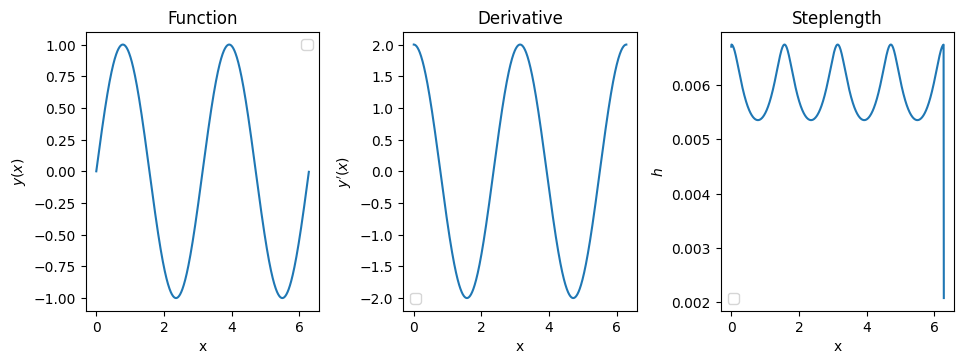

In [172]:
x_vals, y_vals, data = rk_32(0, 2*np.pi, np.array([0,2]), func_1c)

h_vals = data["steplengths"]

fig, axs = plt.subplots(ncols = 3, nrows = 1, figsize=(10,4))

axs[0].plot(x_vals, y_vals[:,0])
axs[0].set_ylabel("$y(x)$")
axs[0].set_title("Function")

axs[1].plot(x_vals, y_vals[:,1])
axs[1].set_ylabel("$y'(x)$")
axs[1].set_title("Derivative")

axs[2].plot(x_vals, h_vals)
axs[2].set_ylabel("$h$")
axs[2].set_title("Steplength")


for ax in axs:
    ax.set_xlabel("x")
    ax.legend()

plt.tight_layout(pad=2.0, w_pad=1.0, h_pad=1.0)

Forklaring på variasjonen i steglengde:

Vi ser at vi har lav steglengde ved ekstremalpunktene, og høyere steglengde imellom. Dette kommer av at i området mellom ekstremalpunktene ser funksjonen mer eller mindre lineær ut, som vil si at den deriverte ikke endrer seg i særlig grad. Det vil si at vi får mindre feil om vi tar et stort seg ved hjelp av den deriverte. Rundt ekstremalpunktene endrer den deriverte seg mye, slik at feilen blir stor om vi tar lange steg. Derfor må steglengden reduseres. Irregulariteten på slutten av grafen for steglengde kan forklares med at nest siste steg tilfeldigvis tok oss veldig nær x_end, slik at det siste steget blir lite av den grunn.

##### Oppgave 1d)

In [173]:
def solution_1b(x):
    """
    Solution to 1b
    
    Args:
        x (arraylike)

    Returns:
        (arraylike)
    """
    return np.sin(2*x)


y_anal = solution_1b(2*np.pi)

n_vals = 100
tol_vals = np.logspace(-7, -1, n_vals)
log_tol_vals = np.log10(tol_vals)

alpha_vals = np.linspace(0.1, 0.9, n_vals)

final_y_vals = np.zeros(n_vals)

timesteps = np.zeros(n_vals)

for i, tol in enumerate(tol_vals):
    x_vals, y_vals, data = rk_32(0, 2*np.pi, np.array([0,2]), func_1c, tol = tol)
    final_y_vals[i] = y_vals[-1, 0]

for i, alpha in enumerate(alpha_vals):
    x_vals, y_vals, data = rk_32(0, 2*np.pi, np.array([0,2]), func_1c, alpha = alpha)
    timesteps[i] = data["timesteps"]
    
error = abs(final_y_vals - y_anal)


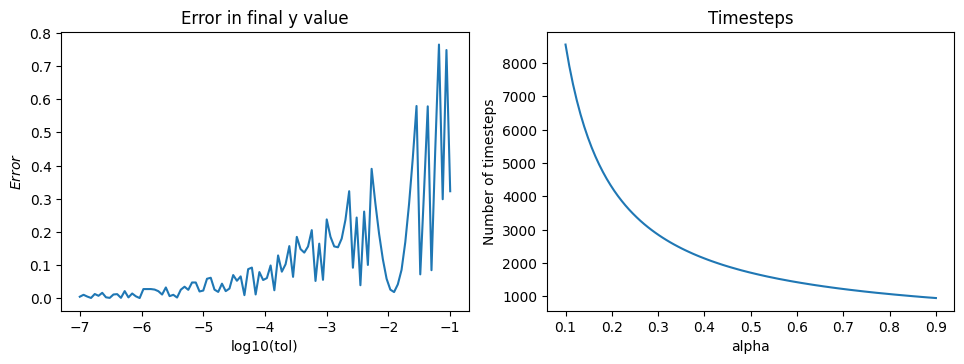

In [174]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize=(10,4))

axs[0].plot(log_tol_vals, error)
axs[0].set_xlabel("log10(tol)")
axs[0].set_ylabel("$Error$")
axs[0].set_title("Error in final y value")

axs[1].plot(alpha_vals, timesteps)
axs[1].set_xlabel("alpha")
axs[1].set_ylabel("Number of timesteps")
axs[1].set_title("Timesteps")

plt.tight_layout(pad=2.0, w_pad=1.0, h_pad=1.0)

Diskusjon:

Vi ser at bla bla bla

##### Oppgave 1e)

In [175]:
def secant_method(g, z0, z1, tol):
    """
    Finds root of function g.
    
    Args:
        g (function): x-value at initial condition
        z0 (float): First guess
        z1 (float): Second guess
        tol (float): Inaccuracy tolerance

    Returns:
        z (float): A root of the function.
    """

    zpp = z0
    zp = z1
    z = ( zpp*g(zp)-zp*g(zpp) ) / ( g(zp) - g(zpp) )
    while abs(zp-z) > tol:
        zpp = zp
        zp = z
        z = ( zpp*g(zp)-zp*g(zpp) ) / ( g(zp) - g(zpp) )

    return z

def test_func(z):
    return z + np.sin(z) + np.cos(z)

test_root = round(secant_method(test_func, 0, 1, 1e-3), 2)

print(f"Roten er: {test_root}")

print(f"Funksjonsverdi for z = {round(test_root - 0.01, 2)}: {test_func(test_root - 0.01)}")
print(f"Funksjonsverdi for z = {round(test_root + 0.01, 2)}: {test_func(test_root + 0.01)}")


Roten er: -0.46
Funksjonsverdi for z = -0.47: -0.0313179971837394
Funksjonsverdi for z = -0.45: 0.015481568241446642


Siden funksjonen skifter fortegn på intervallet $[-0.47, -0.45]$ vet vi at punktet vi har kommet frem til er en rot.

##### Oppgave 1f)

In [176]:
def bvp_solver(ivp_solver, x_init, x_end, y_init, y_end, f, dy_guess_1, dy_guess_2, tol = 1e-7):
    """
    Solves a scalar bvp.
    
    Args:
        ivp_solver (float):
        x_init (float):
        x_end (float):
        y_init (array): Array of length 2.
        y_end (array): Array of length 2.
        f (function): Function for evaluating boundary condition
        dy_guess_1 (float): First guess for dy at x_init
        dy_guess_2 (float): Second guess for dy at x_init

    Returns:
        x_vals_all (np array): Array of size n
        y_vals_all (np array): Array of size (n, 2)
    """

    x_vals_1, y_vals_1 = ivp_solver(x_init, x_end, [y_init, dy_guess_1], f)[:2]
    x_vals_2, y_vals_2 = ivp_solver(x_init, x_end, [y_init, dy_guess_2], f)[:2]

    y_vals_all = [y_vals_1[:,0], y_vals_2[:,0]]
    x_vals_all = [x_vals_1, x_vals_2]
    
    ypp = y_vals_1[-1, 0]
    yp = y_vals_2[-1, 0]

    zpp = dy_guess_1
    zp = dy_guess_2

    z = ( zpp*(yp-y_end)-zp*(ypp-y_end)) / ( yp - ypp )

    while abs(zp-z) > tol:
        zpp = zp
        zp = z

        x_vals, y_vals = ivp_solver(x_init, x_end, [y_init, z], f)[:2]
        x_vals_all.append(x_vals)
        y_vals_all.append(y_vals[:,0])

        ypp = yp
        yp = y_vals[-1, 0]

        z = ( zpp*(yp-y_end)-zp*(ypp-y_end)) / ( yp - ypp )

    return x_vals_all, y_vals_all


    

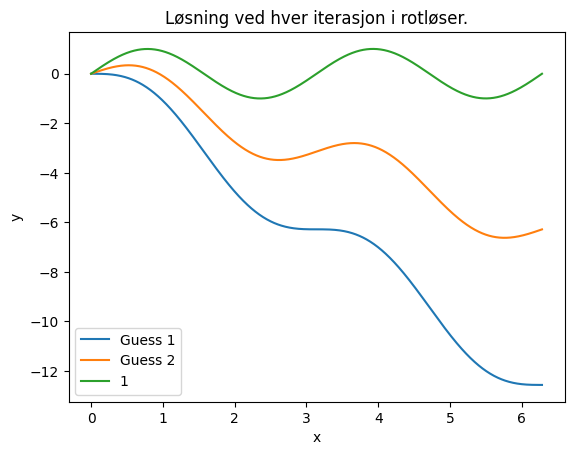

In [177]:

fig, ax = plt.subplots()

x_vals_all, y_vals_all = bvp_solver(rk_32, 0, 2*np.pi, 0, 0, func_1c, 0, 1)

ax.plot(x_vals_all[0], y_vals_all[0], label = f"Guess 1")
ax.plot(x_vals_all[1], y_vals_all[1], label = f"Guess 2")

for i in range(2, len(x_vals_all)):
    ax.plot(x_vals_all[i], y_vals_all[i], label = f"{i-1}")

ax.set_title("Løsning ved hver iterasjon i rotløser.")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()


##### Oppgave 1g)

C:\Users\Einar\AppData\Local\Temp\ipykernel_12740\3453201336.py:60: RuntimeWarning: divide by zero encountered in scalar divide
  h = alpha*h*(tol/est)**(1/3)


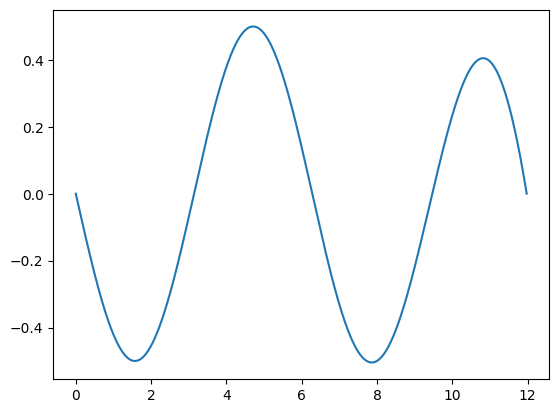

In [178]:
def func_1g(x,  y):
    """
    Function for right hand side of systems of equations from y'' = y + sin(x)
    
    Args:
        x (float)
        y (array): Array of length 2.

    Returns:
        (array): Array of length 2
    """
    return np.array([y[1], y[0]+np.sin(x)])
    

x_vals_all, y_vals_all = bvp_solver(rk_32, 0, 12, 0, 0, func_1g, 0, 1)

fig, ax = plt.subplots()

ax.plot(x_vals_all[-1], y_vals_all[-1])



##### Oppgave 1h)

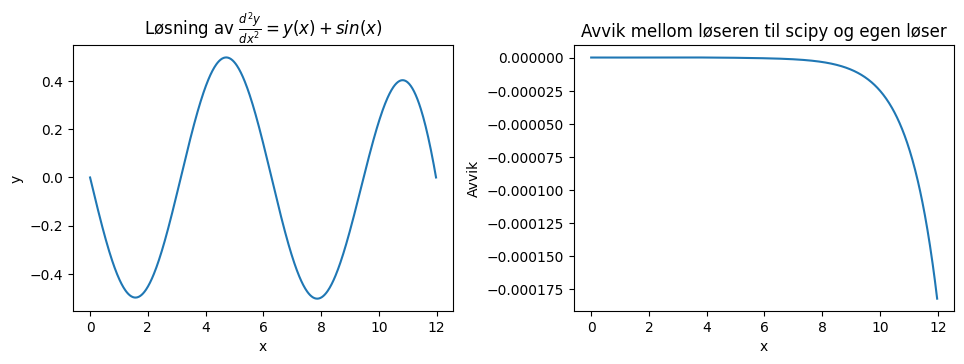

In [179]:
from scipy.integrate import solve_bvp

def bc(ya, yb):
    #Boundary conditions y(0)=y(12) = 0
    return np.array([ya[0], yb[0]])

x_vals = x_vals_all[-1]
y_guess = np.zeros((2, len(x_vals)))

sol = solve_bvp(func_1g, bc, x_vals, y_guess)

fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 4))
axs[0].plot(sol.x, sol.y[0])
axs[0].set_title("Løsning av $\\frac{d^2y}{dx^2} = y(x) + sin(x)$")
axs[0].set_ylabel("y")

axs[1].plot(sol.x, sol.y[0]-y_vals_all[-1])
axs[1].set_title("Avvik mellom løseren til scipy og egen løser")
axs[1].set_ylabel("Avvik")


for ax in axs:
    ax.set_xlabel("x")

plt.tight_layout(pad=2.0, w_pad=1.0, h_pad=1.0)
plt.show()

Kommentarer:

* Sammenligning av resultater i g og h
* Kommentarer på avviket
* Hvilken løser vil vi foretrekke?

### Oppgave 2

##### Oppgave 2a)

In [180]:
def complex_to_real(M):
    """
    Converts nxn complex matrix to a real vector.
    
    Args:
        M (np array): Array of size (n, n)

    Returns:
        (np array): Array of size (2*n*n)
    """
    return np.concatenate((np.real(M).flatten(), np.imag(M).flatten()))

def real_to_complex(m):
    """
    Converts real vector of size 8 to a 2x2 complex matrix
    
    Args:
        m (np array): Array of size 8

    Returns:
        (np array): Array of size (2, 2)
    """
    return np.reshape(m[0:4] + m[4:]*1j, (2,2))

# Test of functions
test_array = np.array([1,2,3,4,5,6,7,8])
print(f"Original array: {test_array}")
complex = real_to_complex(test_array)
print(f"Converted to complex: {complex}")
real = complex_to_real(complex)
print(f"Converted back to real: {real}")

Original array: [1 2 3 4 5 6 7 8]
Converted to complex: [[1.+5.j 2.+6.j]
 [3.+7.j 4.+8.j]]
Converted back to real: [1. 2. 3. 4. 5. 6. 7. 8.]


##### Oppgave 2b)

In [181]:
def merge(m1,m2,m3,m4):
    """
    Concatenates 4 vectors into 1.
    
    Args:
        m1, m2, m3, m4 (np array): Array

    Returns:
        (np array)
    """
    return np.concatenate((m1,m2,m3,m4))

def split(m):
    """
    Splits an array into arrays of length 8.
    
    Args:
        m (np array): Array of length muliple of 8.

    Returns:
        (np array): Array containing arrays of length 8.
    """
    return np.split(m, range(0, len(m), 8))[1:]


#Testing
test_array = np.arange(0, 32)
splitted = split(test_array)
merged = merge(*splitted)

print(f"Original array: {test_array}")
print(f"Splitted: {splitted}")
print(f"Merged back: {merged}")


Original array: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31]
Splitted: [array([0, 1, 2, 3, 4, 5, 6, 7]), array([ 8,  9, 10, 11, 12, 13, 14, 15]), array([16, 17, 18, 19, 20, 21, 22, 23]), array([24, 25, 26, 27, 28, 29, 30, 31])]
Merged back: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31]


##### Oppgave 2c)

In [182]:
def to_vector(M1, M2, M3, M4):
    """
    Converts 4 complex 2x2 matrices to a real 32x1 vector.
    
    Args:
        M1, M2, M3, M4 (np array): Array of size (2, 2)

    Returns:
        (np array): Array of size 32
    """
    matrices = np.array([M1, M2, M3, M4])
    # Replace with numpy.einsum
    return merge(*[complex_to_real(m) for m in matrices])

def to_matrices(v):
    """
    Converts a real 32x1 vector to 4 2x2 complex matrices.
    
    Args:
        v (np array): Array of size 32

    Returns:
        (np array): Array of 4 arrays of size (2,2).
    """
    # Replace with numpy.einsum
    return [real_to_complex(v) for v in split(v)]


#Testing
test_vector = np.arange(0,32)
matrices = to_matrices(test_vector)
vector = to_vector(*matrices)

print(f"Original array: {test_vector}")
print(f"To matrixes: {matrices}")
print(f"Back to vector: {vector}")





Original array: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31]
To matrixes: [array([[0.+4.j, 1.+5.j],
       [2.+6.j, 3.+7.j]]), array([[ 8.+12.j,  9.+13.j],
       [10.+14.j, 11.+15.j]]), array([[16.+20.j, 17.+21.j],
       [18.+22.j, 19.+23.j]]), array([[24.+28.j, 25.+29.j],
       [26.+30.j, 27.+31.j]])]
Back to vector: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31.]


Fra dette kan vi enkelt skrive ned vektoren $\vec{v}$:

$\vec{v} =[ 
Re(\gamma_{11}),  Re(\gamma_{12}), Re(\gamma_{21}), Re(\gamma_{22}), \\
Im(\gamma_{11}), Im(\gamma_{12}), Im(\gamma_{21}), Im(\gamma_{22}), \\
Re(\tilde{\gamma}_{11}), Re(\tilde{\gamma}_{12}), Re(\tilde{\gamma}_{21}), Re(\tilde{\gamma}_{22}), \\
Im(\tilde{\gamma}_{11}), Im(\tilde{\gamma}_{12}), Im(\tilde{\gamma}_{21}), Im(\tilde{\gamma}_{22}), \\
Re(\omega_{11}), Re(\omega_{12}), Re(\omega_{21}), Re(\omega_{22}), \\
Im(\omega_{11}), Im(\omega_{12}), Im(\omega_{21}), Im(\omega_{22}), \\
Re(\tilde{\omega}_{11}), Re(\tilde{\omega}_{12}), Re(\tilde{\omega}_{21}), Re(\tilde{\omega}_{22}), \\
Im(\tilde{\omega}_{11}), Im(\tilde{\omega}_{12}), Im(\tilde{\omega}_{21}), Im(\tilde{\omega}_{22})
]$

##### Oppgave 2d)

In [183]:
def derivative(v, epsilon, delta = 0.01):
    """
    Finds the derivative of v using the Usadel equations.
    
    Args:
        v (np array): Array of size 32

    Returns:
        (np array): Array of size 32
    """

    gamma, gamma_tilde, omega, omega_tilde = to_matrices(v)

    N = np.linalg.inv(np.identity(2)-gamma@gamma_tilde)
    N_tilde = np.linalg.inv(np.identity(2)-gamma_tilde@gamma)

    d_gamma = omega
    d_gamma_tilde = omega_tilde
    d_omega = -2j*(epsilon + delta*1j)*gamma - 2*omega@N_tilde@gamma_tilde@omega
    d_omega_tilde = -2j*(epsilon + delta*1j)*gamma_tilde - 2*omega_tilde@N@gamma@omega_tilde

    return to_vector(d_gamma, d_gamma_tilde, d_omega, d_omega_tilde)



##### Oppgave 2e)

In [184]:
def equation(x, vec, epsilon = 1):
    """
    Finds the derivatives of a list of 32x1 vectors using the Usadel equations.
    
    Args:
        x (np array): List of positions
        y (np array): Array containing 32x1 vectors.

    Returns:
        (np array): Array of the derivatives of the vectors in vec.
    """
    # Replace this with numpy.einsum
    return np.array([derivative(v, epsilon) for v in vec.T]).T


##### Oppgave 2f)

In [185]:
def bc_2f(v_left, v_right, if_param = 3):
    """
    Border condition avaluation for task 2f.
    
    Args:
        v_left (np array): 
        v_right (np array): 
        if_param (float, optional):

    Returns:
        (np array): Array of size 32
    """
    gamma_l, gamma_tilde_l, omega_l, omega_tilde_l = to_matrices(v_left)
    gamma_r, gamma_tilde_r, omega_r, omega_tilde_r = to_matrices(v_right)

    c1 = omega_l - 1/if_param*gamma_l
    c2 = omega_tilde_l - 1/if_param*gamma_tilde_l
    c3 = omega_r + 1/if_param*gamma_r
    c4 = omega_tilde_r + 1/if_param*gamma_tilde_r

    return to_vector(c1,c2,c3,c4)

##### Oppgave 2g)

In [186]:
l = 1
m = 101

epsilon_vals = [0,1,2]

x = np.linspace(0, l, m)
y = np.zeros((32, m))

x_vals = []
y_vals = []

for epsilon, i in enumerate(epsilon_vals):
    sol = solve_bvp(lambda x, y: equation(x, y, epsilon = epsilon), bc_2f, x, y)
    x_vals.append(sol.x)
    y_vals.append(sol.y)
    


##### Oppgave 2h)

In [187]:
def density(v):

    p_3 = np.diag([1,1,-1,-1])
    gamma, gamma_tilde, omega, omega_tilde = to_matrices(v)
    I = np.identity(2)
    N = np.linalg.inv(I-gamma@gamma_tilde)
    N_tilde = np.linalg.inv(I-gamma_tilde@gamma)
    g = np.block([[2*N-I, 2*N@gamma], [-2*N_tilde@gamma_tilde, -2*N_tilde + I]])

    density = np.real(np.trace(p_3@g))/4

    return density

def densities(V):

    densities = np.zeros(len(V.T))
    for i, v in enumerate(V.T):
        densities[i] = density(v)

    return densities

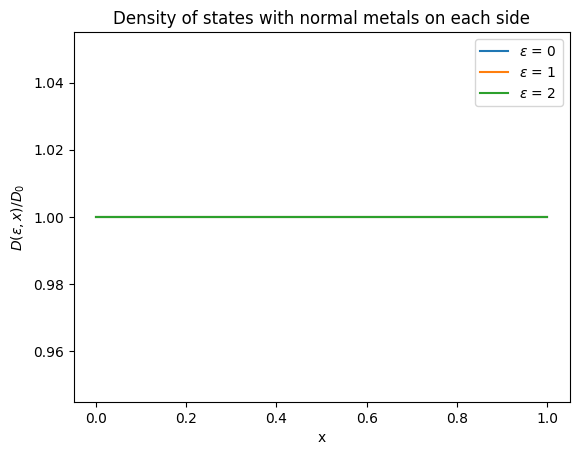

In [188]:
fig, ax = plt.subplots()

for i in range(len(y_vals)):
    ax.plot(x_vals[i], densities(y_vals[i]), label = f"$\\epsilon$ = {epsilon_vals[i]}")

ax.set_xlabel("x")
ax.set_ylabel("$D(\\epsilon, x)/D_0$")
ax.set_title("Density of states with normal metals on each side")

ax.legend()

Vi har vanlige metaller på hver side, så vi forventer ingen effekter av noe slag. Med andre ord burde tilstandstettheten være 1 overalt.

##### Oppgave 2i)

In [189]:
def bc_2i(v_left, v_right, epsilon = 1, delta = 0.01, if_param = 3, phase_diff = 0):
    """
    Border condition evaluation for task 2i.
    
    Args:
        v_left (np array): 
        v_right (np array): 
        if_param (float, optional):

    Returns:
        (np array): Array of size 32
    """
    gamma_l, gamma_tilde_l, omega_l, omega_tilde_l = to_matrices(v_left)
    gamma_r, gamma_tilde_r, omega_r, omega_tilde_r = to_matrices(v_right)

    v_minus = np.atanh(-1/(epsilon + 1j*delta))
    v_plus = np.atanh(1/(epsilon + 1j*delta))
    s_plus = np.sinh(v_plus)
    s_minus = np.sinh(v_minus)
    c_plus = np.cosh(v_plus)
    c_minus = np.cosh(v_minus)  

    gamma_R = np.fliplr(np.diag([s_plus/(1+c_plus), s_minus/(1+c_minus)]))
    gamma_tilde_R = np.fliplr(np.diag([s_minus/(1+c_minus), s_plus/(1+c_plus)]))

    gamma_L = gamma_R*np.exp(1j*phase_diff)
    gamma_tilde_L = gamma_tilde_R*np.exp(-1j*phase_diff)

    I = np.identity(2)

    N_L = np.linalg.inv(I-gamma_L@gamma_tilde_L)
    N_tilde_L = np.linalg.inv(I-gamma_tilde_L@gamma_L)
    N_R = np.linalg.inv(I-gamma_R@gamma_tilde_R)
    N_tilde_R = np.linalg.inv(I-gamma_tilde_R@gamma_R)

    c1 = omega_l + 1/if_param*(I-gamma_l@gamma_L)@N_L@(gamma_L-gamma_l)
    c2 = omega_tilde_l + 1/if_param*(I-gamma_tilde_l@gamma_L)@N_tilde_L@(gamma_tilde_L-gamma_tilde_l)
    c3 = omega_r - 1/if_param*(I-gamma_r@gamma_R)@N_R@(gamma_R-gamma_r)
    c4 = omega_tilde_r - 1/if_param*(I-gamma_tilde_r@gamma_R)@N_tilde_R@(gamma_tilde_R-gamma_tilde_r)

    return to_vector(c1,c2,c3,c4)


##### Oppgave 2j)

C:\Users\Einar\AppData\Local\Temp\ipykernel_12740\1884318427.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


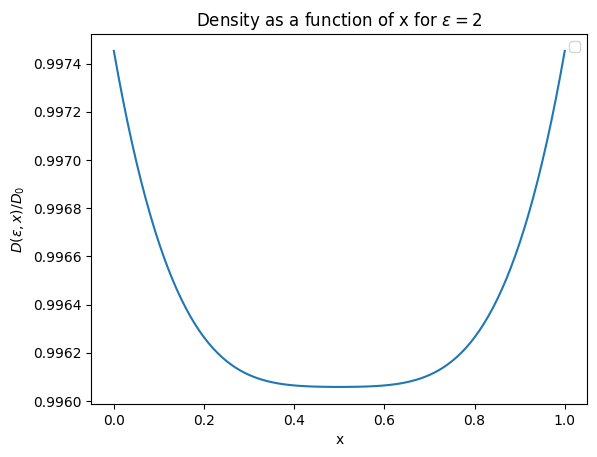

In [ ]:
l = 1
m = 101

epsilon = 2

x = np.linspace(0, l, m)
y = np.zeros((32, m))

fig, ax = plt.subplots()

sol = solve_bvp(lambda x, y: equation(x, y, epsilon = epsilon), lambda v_left, v_right: bc_2i(v_left, v_right, epsilon = epsilon), x, y)
dens = densities(sol.y)
ax.plot(sol.x, dens)
ax.set_xlabel("x")
ax.set_ylabel("$D(\\epsilon, x)/D_0$")
ax.set_title("Density of states as a function of x for $\\epsilon = 2$")

Vi har nå to superledere på hver side av metallet. Disse danner cooper-par på hver side av metallet. Ved $\epsilon = 2$, dvs. at differansen mellom energien til elektronet og fermienergien er 2 ganger så stort som båndgapet, er den normerte tilstanstettheten i superlederne noe høyere enn 1 (som vi ser av plottet i introduksjonen). Det vil si at tilstandstettheten må ha blitt lavere i metallet i mellom.

Fermienergi: Det høyeste energinivået elektroner i et fast stoff okkuperer ved det absolutte nullpunkt.

##### Oppgave 2k)

C:\Users\Einar\AppData\Local\Temp\ipykernel_12740\2250179972.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[j].legend()


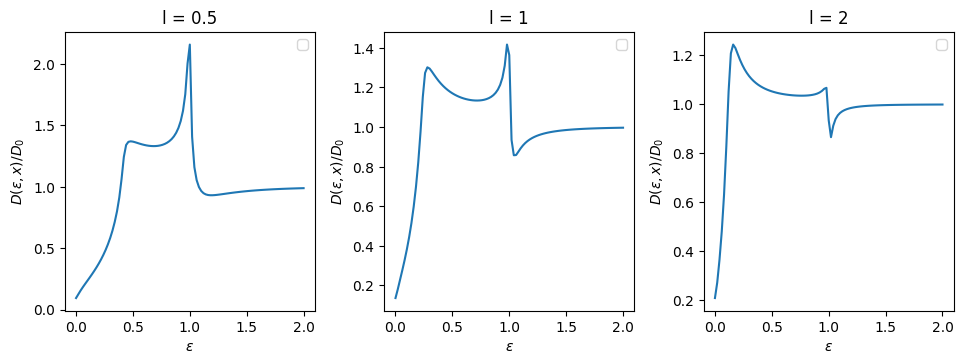

In [191]:
m = 101

#Denne må endres til 0.5, 1 og 2 før innlevering
lengths = [0.5, 1, 2]


epsilons_2l = [2, 1.5, 1, 0.5, 0]

fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (10,4))

for j, l in enumerate(lengths):

    x = np.linspace(0, l, m)
    y = np.zeros((32, m))

    if l == 1:
        y_2l = np.zeros((len(epsilons_2l), 32,m))
        x_2l = x

    epsilon_vals = np.linspace(2, 0, m)

    densities = np.zeros(len(epsilon_vals))

    for i, epsilon in enumerate(epsilon_vals):
        sol = solve_bvp(lambda x, y: equation(x, y, epsilon = epsilon), lambda v_left, v_right: bc_2i(v_left, v_right, epsilon = epsilon), x, y)
        densities[i] = density(sol.y.T[(m-1)//2])

        if l == 1 and (epsilon in epsilons_2l):
            y_2l[np.where(epsilons_2l == epsilon)] = sol.y
        y = sol.y

    axs[j].plot(epsilon_vals, densities)
    axs[j].set_title(f"l = {l}")
    axs[j].set_xlabel("$\\epsilon$")
    axs[j].set_ylabel("$D(\\epsilon, x)/D_0$")
    axs[j].legend()

plt.tight_layout(pad=2.0, w_pad=1.0, h_pad=1.0)

Note: Vi ser bare på energier på oversiden av fermienergien, dvs $\epsilon > 0$

Vi ser at endringene i tilstandstettheten blir mindre prominente for høyere verdier av $l$. Gapet er tydeligst for $0 < \epsilon < 1$, dvs mellom 1 og 2 ganger fermienergien.

Kommentarer:

* Hva skjer med minigapet når lengden øker?

$\epsilon = \frac{E - E_F}{|\Delta|}$

##### Oppgave 2l)

<>:30: SyntaxWarning: invalid escape sequence '\e'
<>:30: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Einar\AppData\Local\Temp\ipykernel_12740\1920129186.py:30: SyntaxWarning: invalid escape sequence '\e'
  ax.plot(x_2l, current_integrands(y_2l[i]), label = f"$\epsilon$ = {epsilon}")


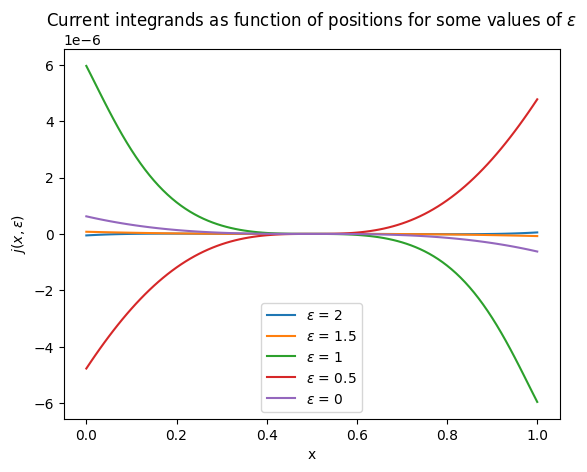

In [192]:
def current_integrand(v):
    
    gamma, gamma_tilde, omega, omega_tilde = to_matrices(v)
    p_3 = np.diag([1,1,-1,-1])
    I = np.identity(2)
    N = np.linalg.inv(I-gamma@gamma_tilde)
    N_tilde = np.linalg.inv(I-gamma_tilde@gamma)
    g = np.block([[2*N-I, 2*N@gamma], [-2*N_tilde@gamma_tilde, -2*N_tilde + I]])

    dN = N@(omega@gamma_tilde + gamma@omega_tilde)@N
    dN_tilde = N_tilde@(omega_tilde@gamma + gamma_tilde@omega)@N_tilde
    dg = np.block([[dN, N@omega + dN@gamma], [-N_tilde@omega_tilde-dN_tilde@gamma_tilde, -dN_tilde]])

    j = np.real(np.trace(p_3@(g@dg - dg@g)))

    return j

def current_integrands(V):

    integrands = np.zeros(len(V.T))
    for i, v in enumerate(V.T):
        integrands[i] = current_integrand(v)

    return integrands


fig, ax = plt.subplots()

for i, epsilon in enumerate(epsilons_2l):
    ax.plot(x_2l, current_integrands(y_2l[i]), label = f"$\epsilon$ = {epsilon}")

ax.set_xlabel("x")
ax.set_ylabel("$j(x, \\epsilon)$")
ax.set_title("Current integrands as function of positions for some values of $\\epsilon$")
ax.legend()



##### Oppgave 2m)

C:\Users\Einar\AppData\Local\Temp\ipykernel_12740\3711549695.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


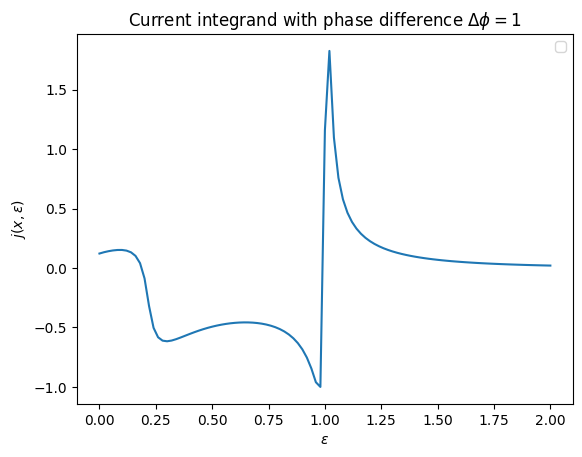

In [193]:
m = 101
l = 1
phase_diff = 1

fig, ax = plt.subplots()


x = np.linspace(0, l, m)
y = np.zeros((32, m))

epsilon_vals = np.linspace(2, 0, 101)

current_integrands = np.zeros(len(epsilon_vals))

for i, epsilon in enumerate(epsilon_vals):
    sol = solve_bvp(lambda x, y: equation(x, y, epsilon = epsilon), lambda v_left, v_right: bc_2i(v_left, v_right, epsilon = epsilon, phase_diff = phase_diff), x, y)
    current_integrands[i] = current_integrand(sol.y.T[(m-1)//2])
    y = sol.sol(x)  # To ensure the new guess is of the same dimension. solve_bvp can add y_values if the tolerance is not met.

ax.plot(epsilon_vals, current_integrands)
ax.set_title("Current integrand with phase difference $\\Delta \\phi = 1$")
ax.set_xlabel("$\\epsilon$")
ax.set_ylabel("$j(x, \\epsilon)$")
ax.legend()

##### Oppgave 2n)

C:\Users\Einar\AppData\Local\Temp\ipykernel_12740\1393221408.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


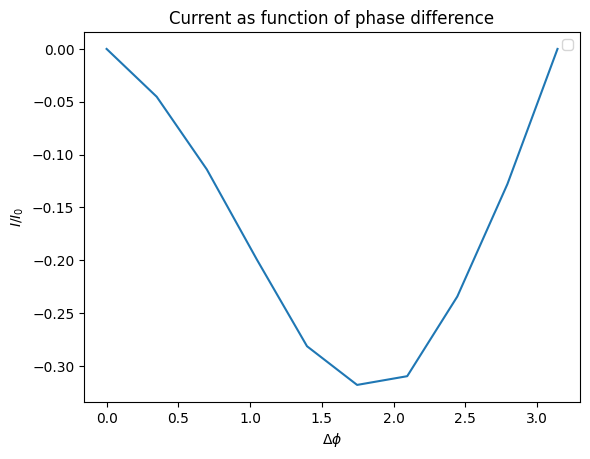

In [194]:
m = 101
l = 1
phase_diffs = np.linspace(0, np.pi, 10)

fig, ax = plt.subplots()

x = np.linspace(0, l, m)
y = np.zeros((32, m))

epsilon_vals = np.linspace(2, 0, 51) # Save som computation

currents = np.zeros(len(phase_diffs))

for j, phase_diff in enumerate(phase_diffs):
    
    current_integrands = np.zeros(len(epsilon_vals))
    for i, epsilon in enumerate(epsilon_vals):
        sol = solve_bvp(lambda x, y: equation(x, y, epsilon = epsilon), lambda v_left, v_right: bc_2i(v_left, v_right, epsilon = epsilon, phase_diff = phase_diff), x, y)
        current_integrands[i] = current_integrand(sol.y.T[(m-1)//2])
        y = sol.sol(x)  # To ensure the new guess is of the same dimension. solve_bvp can add y_values if the tolerance is not met.

    integral = sp.integrate.simpson(current_integrands, epsilon_vals)
    currents[j] = -integral


ax.plot(phase_diffs, currents)
ax.set_title("Current as function of phase difference")
ax.set_xlabel("$\\Delta \\phi$")
ax.set_ylabel("$I/I_0$")
ax.legend()